## Fit to res Bin Analyzer

Ingrids code works, output plotted here

Y axis is ratio of contributations of both standard profiles

In [1]:
import matplotlib.pyplot as plt
import csv
shape = []
obs = []
eshape = []
with open('shapes.dat', mode='r', encoding='ascii') as file:
    reader = csv.reader(file,delimiter=' ')
    for row in reader:
        obs.append(int(row[0][17:22]))
        shape.append(float(row[1]))
        eshape.append(float(row[2]))
        
plt.errorbar(obs,shape,eshape, fmt='o')


FileNotFoundError: [Errno 2] No such file or directory: 'shapes.dat'

### Next step

It may do well to do this analysis bin by bin, or in bin cohorts. This is because we see different variations

### Generate Orthogonal Template

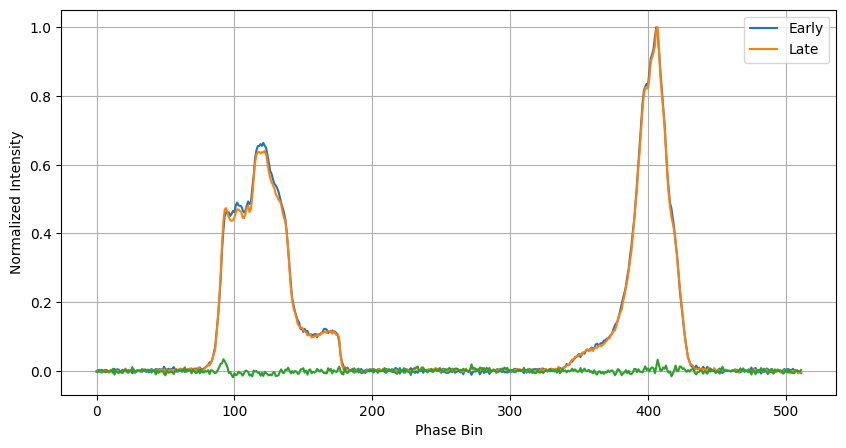

In [2]:
import numpy as np
import psrchive
from pathlib import Path
from scipy.signal import correlate
from scipy.fft import fft, ifft
import matplotlib.pyplot as plt

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


template = "0737_template_L_coherent.fits.smasc"

template_ar = psrchive.Archive.load(template)

template_ar.dedisperse()
template_ar.remove_baseline()
template_ar.fscrunch()
template_ar.tscrunch()
template_ar.pscrunch()

template_prof = template_ar.get_Profile(0, 0, 0)
template_data = template_prof.get_amps()
template_profile = np.array(template_data).flatten()

template_profile /= np.max(template_profile)
def fractional_shift(profile, shift_bins):
    n = len(profile)
    # use fourier transform and shift in frequency domain
    freqs = np.fft.fftfreq(n)
    profile_fft = fft(profile)
    phase_ramp = np.exp(-2j * np.pi * freqs * shift_bins)

    shifted_fft = profile_fft * phase_ramp

    shifted = np.real(ifft(shifted_fft))

    return shifted

# Use phase bin residuals from fractional shift
def align_profile(profile, template):
    profile = profile / np.max(np.abs(profile))
    template_norm = template / np.max(np.abs(template))
    
    total_shift = 0.0
    current = profile.copy()
    
    for _ in range(10):  # iterate until shift converges
        corr = correlate(current, template_norm, mode='full')
        lags = np.arange(-(len(template_norm) - 1), len(current))
        peak = np.argmax(corr)
        integer_shift = lags[peak]

        frac_shift = 0.0
        if 0 < peak < len(corr) - 1:
            y1, y2, y3 = corr[peak - 1], corr[peak], corr[peak + 1]
            denom = y1 - 2*y2 + y3
            if denom != 0:
                frac_shift = 0.5 * (y1 - y3) / denom

        shift_this_iter = integer_shift + frac_shift
        
        if abs(shift_this_iter) < 1e-4:
            break
            
        current = fractional_shift(current, -shift_this_iter)
        total_shift += shift_this_iter

    current /= np.max(current)
    return current, total_shift



def load_profile(filename):

    ar = psrchive.Archive.load(filename)

    ar.dedisperse()
    ar.remove_baseline()
    ar.fscrunch()
    ar.tscrunch()
    ar.pscrunch()

    prof = ar.get_Profile(0, 0, 0)
    profile = np.array(prof.get_amps()).flatten()

    aligned_profile, shift = align_profile(profile, template_profile)

    return aligned_profile


template1 = "GUPPI_0737-3039A_55217_11901.project_id.x.shifted.scaled"
template2 = "GUPPI_0737-3039A_58064_27898.project_id.x.shifted.scaled"

alignedTemp1 = load_profile(template1)
alignedTemp2 = load_profile(template2)

plt.figure(figsize=(10,5))
plt.plot(alignedTemp1, label="Early")
plt.plot(alignedTemp2, label="Late")


orth = alignedTemp2 - (np.dot(alignedTemp1,alignedTemp2)/np.dot(alignedTemp1,alignedTemp1)*alignedTemp1)
plt.plot(orth)


plt.xlabel("Phase Bin")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.grid(True)
with open("Template2.ascii", "w") as f:
    for i, amp in enumerate(orth):
        f.write(f"{i} {amp}\n")
plt.show()

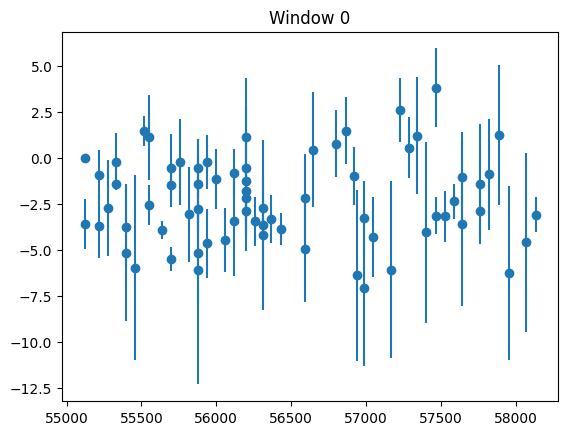

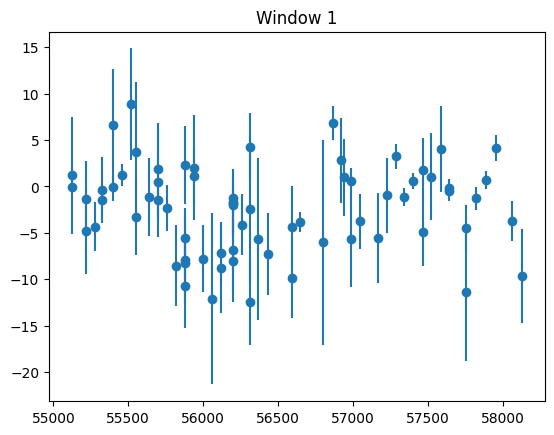

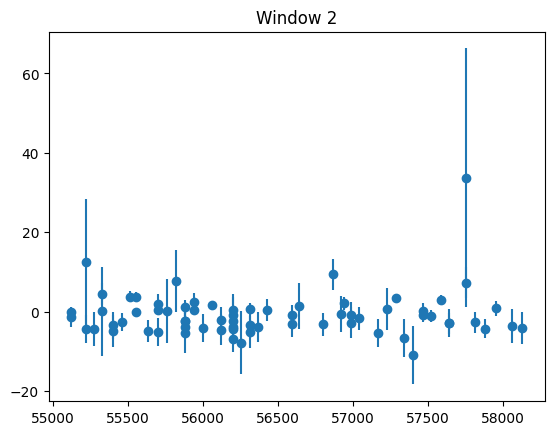

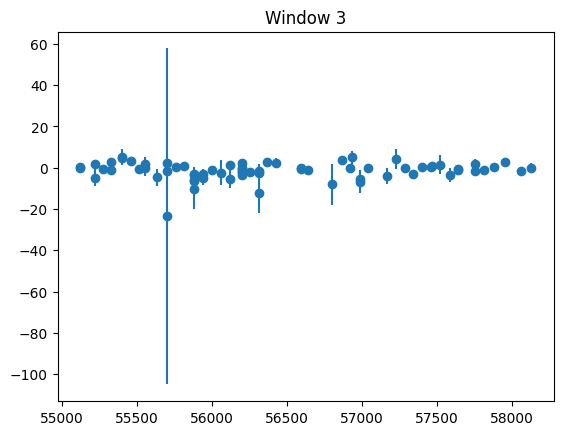

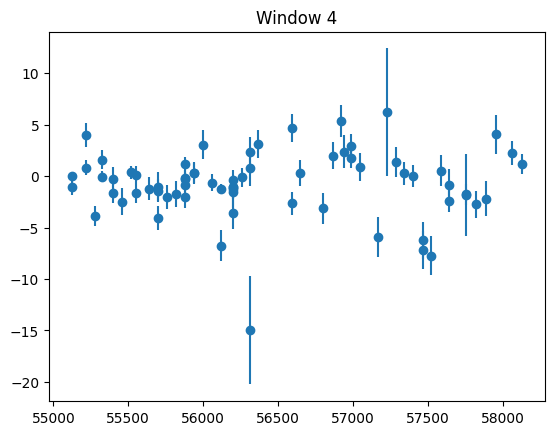

In [3]:
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import csv
import numpy as np

all_obs = []
all_shape = []
all_eshape = []

windows = [[84,90],[100,140],[346,430], [84, 177], [0,511]]

# TEMPLATES (done once)
subprocess.run(
    'for f in *.ascii; do cp "$f" "${f}.tempedit"; done',
    shell=True
)

for i in range(len(windows)):

    # refresh data copies each iteration
    subprocess.run(
        'for f in *.asc; do cp "$f" "${f}.editer"; done',
        shell=True
    )
    subprocess.run(
        'for f in *.ascii; do cp "$f" "${f}.tempedit"; done',
        shell=True
    )

    # apply windowing to templates
    for file in Path(".").glob("*.tempedit"):
        with open(file, mode='r', encoding='ascii') as f:
            lines = f.readlines()

        del lines[windows[i][1]:-1]
        del lines[0:windows[i][0]]

        with open(file, mode='w', encoding='ascii') as f:
            f.writelines(lines)

    # apply windowing to data
    for file in Path(".").glob("*.editer"):
        with open(file, mode='r', encoding='ascii') as f:
            lines = f.readlines()

        del lines[windows[i][1]:-1]
        del lines[0:windows[i][0]]

        with open(file, mode='w', encoding='ascii') as f:
            f.writelines(lines)

    # run fit
    subprocess.run(
        'for f in *.editer; do '
        '/p1/data/timing_data/0737-3039/guppi/ahumph/tarball/fit2res '
        'Template1.ascii.tempedit Template2.ascii.tempedit "$f" "${f}.out" 0; '
        'done',
        shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

    # IMPORTANT FIX: save output before next loop overwrites it
    subprocess.run(f'mv shapes.dat shapes_{i}.dat', shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    shape = []
    obs = []
    eshape = []

    with open(f'shapes_{i}.dat', mode='r', encoding='ascii') as file:
        reader = csv.reader(file, delimiter=' ')
        for row in reader:
            obs.append(int(row[0][17:22]))
            shape.append(float(row[1]))
            eshape.append(float(row[2]))

    obs = np.array(obs)
    shape = np.array(shape)
    eshape = np.array(eshape)

    mask = eshape <= 100

    all_obs.append(obs[mask])
    all_shape.append(shape[mask])
    all_eshape.append(eshape[mask])

    subprocess.run(
        'rm -f *.editer *.tempedit *.editer* *out shapes.dat',
        shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

# FINAL PLOT (each window separate)
for j in range(len(all_obs)):
    plt.figure()
    plt.errorbar(all_obs[j], all_shape[j], all_eshape[j], fmt='o')
    plt.title(f'Window {j}')

plt.show()